# Attack Multiplier Outlier Backtest

This notebook tests whether expected scores improve when unusually large performance residuals are discounted before updating a team's attack multiplier.

> **Which update method produces expected scores closest to actual scores?**


In [1]:
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing pyproject.toml')

ROOT = find_project_root()
DB_PATH = ROOT / 'data' / 'rugby_league_pricing.db'
connection = sqlite3.connect(DB_PATH)
print(DB_PATH)


/workspaces/rugby_league_pricing/data/rugby_league_pricing.db


## 1. Load expected and actual scores

In [3]:
query = '''
SELECT
    e.fixture_id,
    f.match_date,
    f.season,
    f.home_team_id,
    f.away_team_id,
    ht.canonical_name AS home_team,
    at.canonical_name AS away_team,
    e.expected_home_score,
    e.expected_away_score,
    r.home_score,
    r.away_score
FROM expected_scores e
JOIN fixtures f ON e.fixture_id = f.fixture_id
JOIN results r ON e.fixture_id = r.fixture_id
JOIN teams ht ON f.home_team_id = ht.team_id
JOIN teams at ON f.away_team_id = at.team_id
WHERE r.home_score IS NOT NULL
  AND r.away_score IS NOT NULL
ORDER BY f.match_date, e.fixture_id
'''
fixtures = pd.read_sql(query, connection)
fixtures['match_date'] = pd.to_datetime(fixtures['match_date'])
fixtures.head()


,fixture_id,match_date,season,home_team_id,away_team_id,home_team,away_team,expected_home_score,expected_away_score,home_score,away_score
0,2010-01-30_17_8,2010-01-30,2010,17,8,Harlequins RL,Wakefield Trinity,6.0000,34.0000,10,18
1,2010-02-05_11_14,2010-02-05,2010,11,14,Huddersfield Giants,Bradford Bulls,8.0000,26.0000,24,12
2,2010-02-05_1_16,2010-02-05,2010,1,16,Wigan Warriors,Crusaders RL,9.9231,21.7500,38,6
3,2010-02-05_7_6,2010-02-05,2010,7,6,Leeds Rhinos,Castleford Tigers,9.6757,21.6081,10,24
4,2010-02-06_9_4,2010-02-06,2010,9,4,St Helens,Hull FC,17.6000,18.8000,12,32


## 2. Convert to one row per team performance

In [4]:
home = fixtures.rename(columns={
    'home_team_id':'team_id','away_team_id':'opponent_id',
    'home_team':'team','away_team':'opponent',
    'expected_home_score':'expected_score','home_score':'actual_score'
})[['fixture_id','match_date','season','team_id','opponent_id','team','opponent','expected_score','actual_score']].assign(venue='home')

away = fixtures.rename(columns={
    'away_team_id':'team_id','home_team_id':'opponent_id',
    'away_team':'team','home_team':'opponent',
    'expected_away_score':'expected_score','away_score':'actual_score'
})[['fixture_id','match_date','season','team_id','opponent_id','team','opponent','expected_score','actual_score']].assign(venue='away')

performances = pd.concat([home, away], ignore_index=True).sort_values(['team_id','match_date','fixture_id']).reset_index(drop=True)
performances['residual'] = performances['actual_score'] - performances['expected_score']
performances['absolute_residual'] = performances['residual'].abs()
performances.head()


,fixture_id,match_date,season,team_id,opponent_id,team,opponent,expected_score,actual_score,venue,residual,absolute_residual
0,2010-02-05_1_16,2010-02-05,2010,1,16,Wigan Warriors,Crusaders RL,9.9231,38,home,28.0769,28.0769
1,2010-02-12_1_5,2010-02-12,2010,1,5,Wigan Warriors,Hull Kingston Rovers,23.7230,32,home,8.2770,8.2770
2,2010-02-20_12_1,2010-02-20,2010,1,12,Wigan Warriors,Warrington Wolves,16.8451,22,away,5.1549,5.1549
3,2010-02-26_1_3,2010-02-26,2010,1,3,Wigan Warriors,Catalans Dragons,34.9238,58,home,23.0762,23.0762
4,2010-03-05_14_1,2010-03-05,2010,1,14,Wigan Warriors,Bradford Bulls,27.8043,20,away,-7.8043,7.8043


## 3. Define residual outliers

In [5]:
RESIDUAL_SD_THRESHOLD = 1.5
residual_mean = performances['residual'].mean()
residual_sd = performances['residual'].std(ddof=1)
lower = residual_mean - RESIDUAL_SD_THRESHOLD * residual_sd
upper = residual_mean + RESIDUAL_SD_THRESHOLD * residual_sd
performances['is_outlier'] = ~performances['residual'].between(lower, upper)
print(f'Residual mean: {residual_mean:.3f}')
print(f'Residual SD: {residual_sd:.3f}')
print(f'Outlier range: {lower:.3f} to {upper:.3f}')
print(f'Outlier rate: {performances.is_outlier.mean():.2%}')


Residual mean: -1.353
Residual SD: 12.627
Outlier range: -20.293 to 17.588
Outlier rate: 12.13%


In [6]:
performances.loc[performances.is_outlier, ['match_date','team','opponent','expected_score','actual_score','residual']].sort_values('residual', key=lambda s: s.abs(), ascending=False).head(30)


,match_date,team,opponent,expected_score,actual_score,residual
5041,2011-03-20,Warrington Wolves,Harlequins RL,22.5923,82,59.4077
106,2013-04-01,Wigan Warriors,Hull Kingston Rovers,28.8177,84,55.1823
4013,2025-02-15,St Helens,Salford Red Devils,28.8983,82,53.1017
139,2014-04-21,Wigan Warriors,Bradford Bulls,33.2284,84,50.7716
4637,2013-09-19,Huddersfield Giants,Hull FC,25.8934,76,50.1066
4387,2021-07-11,Salford Red Devils,Castleford Tigers,20.6814,70,49.3186
1262,2012-09-01,Hull FC,Bradford Bulls,22.2617,70,47.7383
4643,2014-03-16,Huddersfield Giants,Bradford Bulls,19.4835,66,46.5165
4414,2022-06-26,Salford Red Devils,Wakefield Trinity,27.6742,74,46.3258
4000,2024-07-05,St Helens,Castleford Tigers,52.2019,6,-46.2019


## 4. Alternative residual treatments

In [7]:
CAP_POINTS = 15.0
SHRINK_FACTOR = 0.75
HUBER_K = 1.5
WINSOR_LOWER = performances['residual'].quantile(0.05)
WINSOR_UPPER = performances['residual'].quantile(0.95)

def raw(s): return s

def capped(s): return s.clip(-CAP_POINTS, CAP_POINTS)

def shrink_outliers(s):
    out = s.copy()
    mask = ~s.between(lower, upper)
    out.loc[mask] = out.loc[mask] * SHRINK_FACTOR
    return out

def winsor(s): return s.clip(WINSOR_LOWER, WINSOR_UPPER)

def huber(s): return s.clip(-HUBER_K * residual_sd, HUBER_K * residual_sd)

methods = {'raw': raw, 'cap_points': capped, 'shrink_outliers': shrink_outliers, 'winsor_5_95': winsor, 'huber': huber}
for name, fn in methods.items():
    performances[f'adjusted_residual_{name}'] = fn(performances['residual'])
    performances[f'observed_score_{name}'] = performances['expected_score'] + performances[f'adjusted_residual_{name}']


## 5. Rolling attack multipliers

In [8]:
WINDOW = 5
RECENCY_WEIGHTS = np.arange(1, WINDOW + 1, dtype=float)

def previous_ratio(group, observed_col):
    values = []
    group = group.sort_values(['match_date','fixture_id'])
    for i in range(len(group)):
        history = group.iloc[max(0, i-WINDOW):i]
        if history.empty:
            values.append(np.nan)
            continue
        w = RECENCY_WEIGHTS[-len(history):]
        obs = np.average(history[observed_col], weights=w)
        exp = np.average(history['expected_score'], weights=w)
        values.append(obs / exp if exp > 0 else np.nan)
    return pd.Series(values, index=group.index)

for name in methods:
    col = f'observed_score_{name}'
    performances[f'attack_multiplier_{name}'] = performances.groupby('team_id', group_keys=False).apply(lambda g: previous_ratio(g, col))
    performances[f'prediction_{name}'] = performances['expected_score'] * performances[f'attack_multiplier_{name}']

evaluation = performances.dropna(subset=[f'prediction_{name}' for name in methods]).copy()
print(f'Evaluation rows: {len(evaluation):,}')


Evaluation rows: 6,186


## 6. Main result: which method is closest to actual?

In [9]:
rows = []
for name in methods:
    pred = evaluation[f'prediction_{name}']
    actual = evaluation['actual_score']
    error = actual - pred
    rows.append({
        'method': name,
        'observations': len(evaluation),
        'average_actual': actual.mean(),
        'average_expected': pred.mean(),
        'average_difference_actual_minus_expected': error.mean(),
        'mae': error.abs().mean(),
        'rmse': np.sqrt((error**2).mean()),
        'correlation': actual.corr(pred),
    })
leaderboard = pd.DataFrame(rows).sort_values(['mae','rmse']).reset_index(drop=True)
leaderboard


,method,observations,average_actual,average_expected,average_difference_actual_minus_expected,mae,rmse,correlation
0,cap_points,6186,22.8016,23.0729,-0.2713,10.7446,13.8455,0.3240
1,huber,6186,22.8016,23.0840,-0.2823,10.9178,14.0825,0.3162
2,shrink_outliers,6186,22.8016,23.1380,-0.3363,10.9697,14.1785,0.3131
3,winsor_5_95,6186,22.8016,23.1593,-0.3577,10.9791,14.1657,0.3143
4,raw,6186,22.8016,23.4070,-0.6054,11.2568,14.5986,0.3030


## 7. Improvement versus raw

In [10]:
raw_mae = leaderboard.loc[leaderboard.method.eq('raw'), 'mae'].iloc[0]
raw_rmse = leaderboard.loc[leaderboard.method.eq('raw'), 'rmse'].iloc[0]
comparison = leaderboard.copy()
comparison['mae_improvement_vs_raw'] = raw_mae - comparison['mae']
comparison['rmse_improvement_vs_raw'] = raw_rmse - comparison['rmse']
comparison['mae_percent_improvement'] = comparison['mae_improvement_vs_raw'] / raw_mae
comparison


,method,observations,average_actual,average_expected,average_difference_actual_minus_expected,mae,rmse,correlation,mae_improvement_vs_raw,rmse_improvement_vs_raw,mae_percent_improvement
0,cap_points,6186,22.8016,23.0729,-0.2713,10.7446,13.8455,0.3240,0.5122,0.7531,0.0455
1,huber,6186,22.8016,23.0840,-0.2823,10.9178,14.0825,0.3162,0.3390,0.5161,0.0301
2,shrink_outliers,6186,22.8016,23.1380,-0.3363,10.9697,14.1785,0.3131,0.2871,0.4201,0.0255
3,winsor_5_95,6186,22.8016,23.1593,-0.3577,10.9791,14.1657,0.3143,0.2777,0.4328,0.0247
4,raw,6186,22.8016,23.4070,-0.6054,11.2568,14.5986,0.3030,0.0000,0.0000,0.0000


## 8. Matches immediately after an outlier

In [11]:
evaluation['previous_match_was_outlier'] = evaluation.groupby('team_id')['is_outlier'].shift(1).fillna(False).astype(bool)
after = evaluation[evaluation.previous_match_was_outlier].copy()
rows = []
for name in methods:
    pred = after[f'prediction_{name}']
    actual = after['actual_score']
    error = actual - pred
    rows.append({'method':name,'observations':len(after),'average_difference_actual_minus_expected':error.mean(),'mae':error.abs().mean(),'rmse':np.sqrt((error**2).mean()),'correlation':actual.corr(pred)})
pd.DataFrame(rows).sort_values(['mae','rmse']).reset_index(drop=True)


,method,observations,average_difference_actual_minus_expected,mae,rmse,correlation
0,cap_points,748,-3.3977,11.5800,14.8793,0.3527
1,huber,748,-3.8920,12.0942,15.5706,0.3390
2,shrink_outliers,748,-4.0954,12.2522,15.8821,0.3369
3,winsor_5_95,748,-4.2028,12.3263,15.8773,0.3349
4,raw,748,-5.1257,13.3580,17.4160,0.3140


## 9. Multiplier sensitivity after outliers

In [12]:
rows = []
for name in methods:
    col = f'attack_multiplier_{name}'
    next_mult = performances.groupby('team_id')[col].shift(-1)
    change = (next_mult - performances[col]).loc[performances.is_outlier].dropna()
    rows.append({'method':name,'outlier_updates':len(change),'average_absolute_multiplier_change':change.abs().mean(),'median_absolute_multiplier_change':change.abs().median(),'max_absolute_multiplier_change':change.abs().max()})
pd.DataFrame(rows).sort_values('average_absolute_multiplier_change')


,method,outlier_updates,average_absolute_multiplier_change,median_absolute_multiplier_change,max_absolute_multiplier_change
1,cap_points,748,0.2241,0.2161,0.7853
4,huber,748,0.2786,0.2693,0.9263
2,shrink_outliers,748,0.2812,0.2682,0.8496
3,winsor_5_95,748,0.2976,0.2877,0.9914
0,raw,748,0.3691,0.3490,1.0310


## 10. Inspect extreme cases

In [14]:
cols = ['match_date','team','opponent','expected_score','actual_score','residual'] + [f'adjusted_residual_{n}' for n in methods] + [f'attack_multiplier_{n}' for n in methods]
performances.loc[performances.is_outlier, cols].sort_values('residual', key=lambda s: s.abs(), ascending=False).sample(10).T


,3561,4895,4109,5768,1271,6083,759,706,85,5743
match_date,2010-04-05 00:00:00,2022-09-10 00:00:00,2011-05-20 00:00:00,2010-08-01 00:00:00,2013-03-08 00:00:00,2012-08-31 00:00:00,2012-03-31 00:00:00,2010-05-09 00:00:00,2012-06-29 00:00:00,2026-07-12 00:00:00
team,St Helens,Huddersfield Giants,Salford Red Devils,Crusaders RL,Hull FC,London Broncos,Catalans Dragons,Catalans Dragons,Wigan Warriors,Toulouse Olympique
opponent,Castleford Tigers,Salford Red Devils,Hull Kingston Rovers,Salford Red Devils,Castleford Tigers,St Helens,Widnes Vikings,Crusaders RL,Bradford Bulls,St Helens
expected_score,23.0452,25.7649,27.1570,23.6527,24.6643,23.3021,36.8522,15.9588,47.3608,17.9035
actual_score,52,0,0,60,52,0,76,35,22,46
residual,28.9548,-25.7649,-27.1570,36.3473,27.3357,-23.3021,39.1478,19.0412,-25.3608,28.0965
adjusted_residual_raw,28.9548,-25.7649,-27.1570,36.3473,27.3357,-23.3021,39.1478,19.0412,-25.3608,28.0965
adjusted_residual_cap_points,15.0000,-15.0000,-15.0000,15.0000,15.0000,-15.0000,15.0000,15.0000,-15.0000,15.0000
adjusted_residual_shrink_outliers,21.7161,-19.3237,-20.3677,27.2605,20.5018,-17.4766,29.3609,14.2809,-19.0206,21.0723
adjusted_residual_winsor_5_95,20.9809,-19.9789,-19.9789,20.9809,20.9809,-19.9789,20.9809,19.0412,-19.9789,20.9809


## 11. Actual vs expected plots

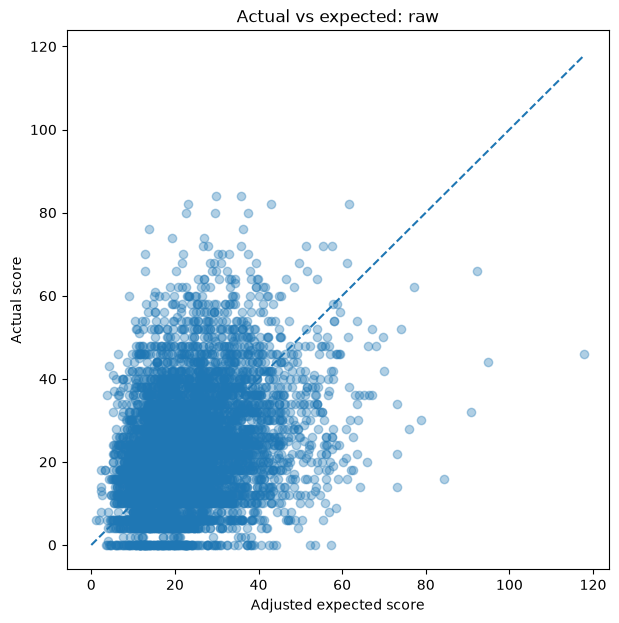

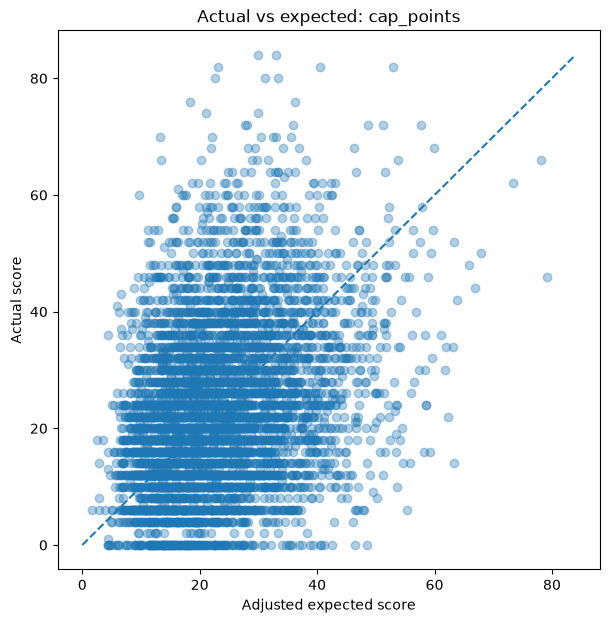

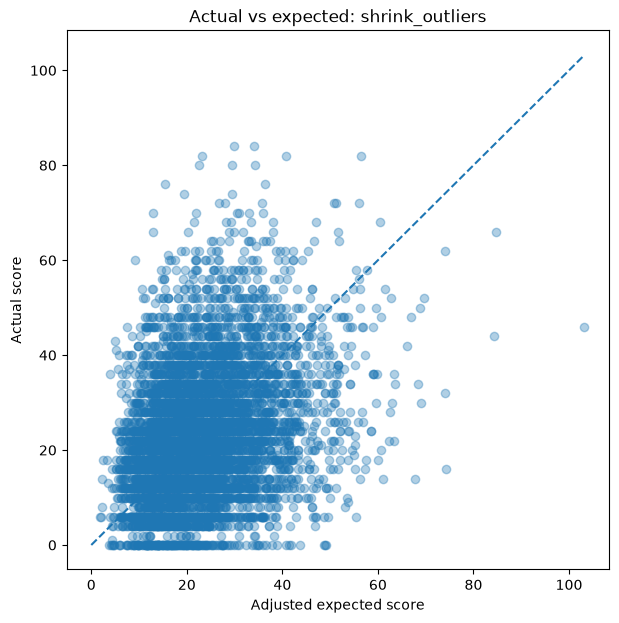

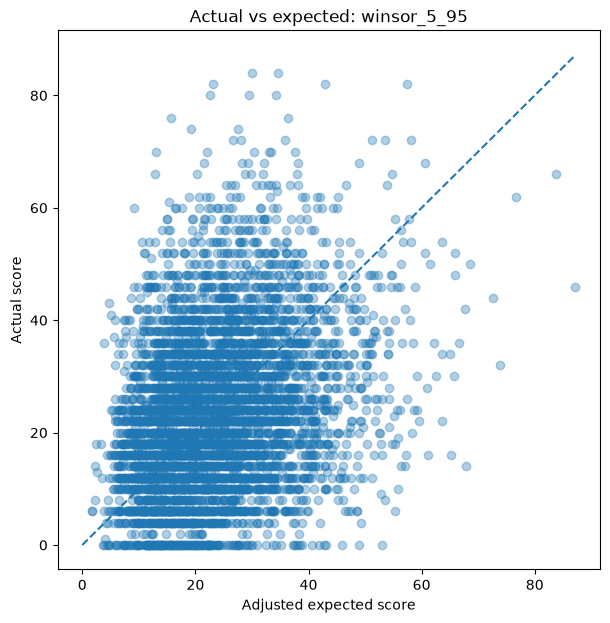

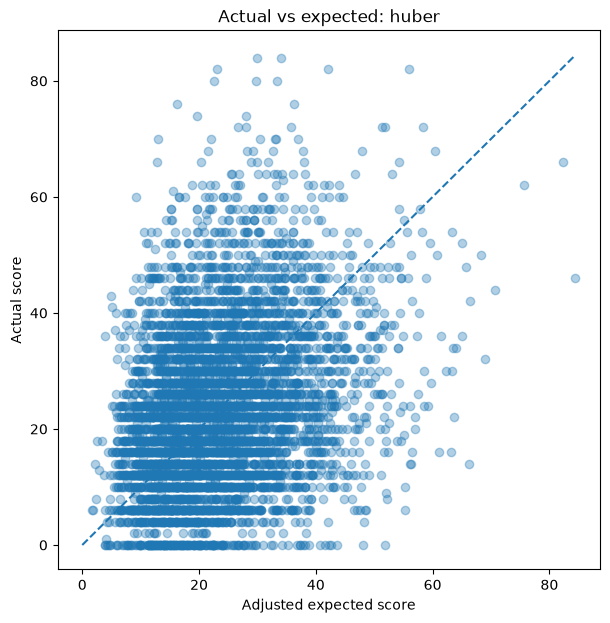

In [15]:
for name in methods:
    pred = evaluation[f'prediction_{name}']
    actual = evaluation['actual_score']
    plt.figure(figsize=(7,7))
    plt.scatter(pred, actual, alpha=0.35)
    lo = min(pred.min(), actual.min())
    hi = max(pred.max(), actual.max())
    plt.plot([lo,hi],[lo,hi],'--')
    plt.xlabel('Adjusted expected score')
    plt.ylabel('Actual score')
    plt.title(f'Actual vs expected: {name}')
    plt.show()


### Smooth Cap Multiplier

In [16]:
def smooth_cap_multiplier(
    raw_multiplier: pd.Series,
    cap_start: float = 0.50,
    max_edit: float = 0.25,
    neutral_multiplier: float = 1.0,
) -> pd.Series:
    """
    Apply a curved cap to multiplier changes around the neutral value.

    Small changes are approximately preserved.
    Larger changes are progressively discounted.
    Changes reach an exact cap once abs(raw_edit) >= cap_start.
    """
    if cap_start <= 0:
        raise ValueError("cap_start must be positive.")

    if max_edit <= 0:
        raise ValueError("max_edit must be positive.")

    raw_edit = raw_multiplier - neutral_multiplier
    edit_magnitude = raw_edit.abs()

    scaled_position = (edit_magnitude / cap_start).clip(upper=1.0)

    scaled_magnitude = max_edit * (
        2 * scaled_position - scaled_position**2
    )

    scaled_edit = np.sign(raw_edit) * scaled_magnitude

    return neutral_multiplier + scaled_edit

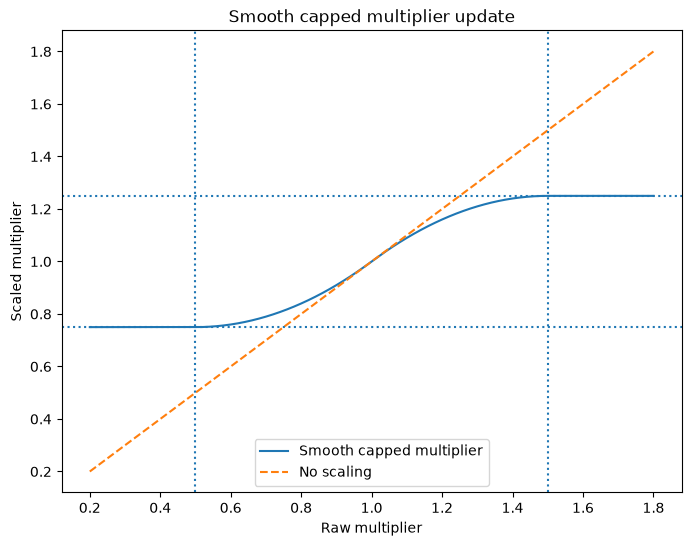

In [17]:
example_raw_multipliers = pd.Series(
    np.linspace(0.20, 1.80, 161)
)

example_scaled_multipliers = smooth_cap_multiplier(
    raw_multiplier=example_raw_multipliers,
    cap_start=0.50,
    max_edit=0.25,
)

curve = pd.DataFrame(
    {
        "raw_multiplier": example_raw_multipliers,
        "scaled_multiplier": example_scaled_multipliers,
    }
)

plt.figure(figsize=(8, 6))

plt.plot(
    curve["raw_multiplier"],
    curve["scaled_multiplier"],
    label="Smooth capped multiplier",
)

plt.plot(
    curve["raw_multiplier"],
    curve["raw_multiplier"],
    "--",
    label="No scaling",
)

plt.axhline(1.25, linestyle=":")
plt.axhline(0.75, linestyle=":")
plt.axvline(1.50, linestyle=":")
plt.axvline(0.50, linestyle=":")

plt.xlabel("Raw multiplier")
plt.ylabel("Scaled multiplier")
plt.title("Smooth capped multiplier update")
plt.legend()
plt.show()

In [18]:
performances["attack_multiplier_smooth_cap"] = (
    smooth_cap_multiplier(
        raw_multiplier=performances["attack_multiplier_raw"],
        cap_start=0.50,
        max_edit=0.25,
    )
)

performances["prediction_smooth_cap"] = (
    performances["expected_score"]
    * performances["attack_multiplier_smooth_cap"]
)

In [19]:
smooth_cap_evaluation = performances.dropna(
    subset=[
        "actual_score",
        "prediction_raw",
        "prediction_smooth_cap",
    ]
).copy()

rows = []

for method_name in ["raw", "smooth_cap"]:
    actual = smooth_cap_evaluation["actual_score"]
    predicted = smooth_cap_evaluation[f"prediction_{method_name}"]

    error = actual - predicted

    rows.append(
        {
            "method": method_name,
            "mean_error": error.mean(),
            "mae": error.abs().mean(),
            "mse": np.mean(error**2),
            "rmse": np.sqrt(np.mean(error**2)),
            "correlation": actual.corr(predicted),
        }
    )

pd.DataFrame(rows).sort_values("mse")

,method,mean_error,mae,mse,rmse,correlation
1,smooth_cap,-0.7811,10.4974,182.0140,13.4913,0.3403
0,raw,-0.6054,11.2568,213.1185,14.5986,0.3030


In [20]:
parameter_results = []

cap_start_values = [0.30, 0.40, 0.50, 0.60, 0.75]
max_edit_values = [0.15, 0.20, 0.25, 0.30, 0.35]

for cap_start in cap_start_values:
    for max_edit in max_edit_values:
        scaled_multiplier = smooth_cap_multiplier(
            raw_multiplier=performances["attack_multiplier_raw"],
            cap_start=cap_start,
            max_edit=max_edit,
        )

        prediction = (
            performances["expected_score"]
            * scaled_multiplier
        )

        valid = (
            performances["actual_score"].notna()
            & prediction.notna()
        )

        actual = performances.loc[valid, "actual_score"]
        predicted = prediction.loc[valid]

        error = actual - predicted

        parameter_results.append(
            {
                "cap_start": cap_start,
                "max_edit": max_edit,
                "mean_error": error.mean(),
                "mae": error.abs().mean(),
                "mse": np.mean(error**2),
                "rmse": np.sqrt(np.mean(error**2)),
                "correlation": actual.corr(predicted),
            }
        )

smooth_cap_grid = (
    pd.DataFrame(parameter_results)
    .sort_values(["mse", "mae"])
    .reset_index(drop=True)
)

smooth_cap_grid.head(20)

,cap_start,max_edit,mean_error,mae,mse,rmse,correlation
0,0.7500,0.1500,-1.0964,10.1190,167.2258,12.9316,0.3675
1,0.6000,0.1500,-1.0492,10.1532,168.6480,12.9865,0.3645
2,0.5000,0.1500,-1.0114,10.1824,169.8317,13.0319,0.3620
3,0.7500,0.2000,-1.0097,10.2110,170.8664,13.0716,0.3599
4,0.4000,0.1500,-0.9711,10.2165,171.1895,13.0839,0.3594
5,0.3000,0.1500,-0.9324,10.2562,172.6782,13.1407,0.3567
6,0.6000,0.2000,-0.9467,10.2707,173.2667,13.1631,0.3552
7,0.7500,0.2500,-0.9229,10.3239,175.2808,13.2394,0.3515
8,0.5000,0.2000,-0.8962,10.3220,175.2969,13.2400,0.3515
9,0.4000,0.2000,-0.8425,10.3839,177.6686,13.3292,0.3475
